# Layer C v4 — Dual-Mode Gravity (air + rail, 53 cities)

**Bocconi 20599 | Multimodal European Transport Disruption ABM**

## Design

Two separate PPML gravity models, one per mode:

$$V^{air}_{ab} = \exp(\mu^{air}_a + \mu^{air}_b - \gamma_{air} \log d_{ab})$$
$$V^{rail}_{ab} = \exp(\mu^{rail}_a + \mu^{rail}_b - \gamma_{rail} \log d_{ab})$$

Each mode has its own distance elasticity ($\gamma_{air} \neq \gamma_{rail}$) and city fixed effects.
Combined weight and modal split are derived from the two predictions:

$$\text{weight}(a,b) = V^{air}_{ab} + V^{rail}_{ab}$$
$$\text{air\_share}(a,b) = V^{air}_{ab} \;/\; (V^{air}_{ab} + V^{rail}_{ab})$$

## Calibration data

- **Air model:** pairs with observed air service (`air_pax > 0`). No distance filter needed — air routes are inherently intercity.
- **Rail model:** pairs with rail service AND `distance >= 100 km`. The 100 km floor excludes commuter-range connections (Amsterdam–Rotterdam 57 km, Amsterdam–Utrecht 35 km) whose GTFS-derived passenger estimates reflect commuter demand, not the intercity travel modelled here.

## References
- Anderson & van Wincoop (2003) — structural gravity / city FEs
- Santos Silva & Tenreyro (2006) — PPML estimator

## 1. Imports and data loading

In [1]:
import os, json
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from math import radians, cos, sin, asin, sqrt

DATA_DIR = "data"
RAIL_MIN_KM = 100   # exclude commuter-range rail from rail calibration

# ── Helpers ──────────────────────────────────────────────────────────────────
def hav(a, b, coord):
    la1,lo1,la2,lo2 = map(radians,[coord[a]["lat"],coord[a]["lon"],
                                   coord[b]["lat"],coord[b]["lon"]])
    dla, dlo = la2-la1, lo2-lo1
    h = sin(dla/2)**2 + cos(la1)*cos(la2)*sin(dlo/2)**2
    return 2*6371.0*asin(sqrt(h))

def city_fe(d, base_d=None):
    """Symmetric city fixed-effects dummy matrix for undirected pairs."""
    f = (pd.get_dummies(d["city_a"], prefix="c")
         .add(pd.get_dummies(d["city_b"], prefix="c"), fill_value=0)
         .astype(float))
    if base_d is not None:
        base = (pd.get_dummies(base_d["city_a"], prefix="c")
                .add(pd.get_dummies(base_d["city_b"], prefix="c"), fill_value=0)
                .astype(float))
        cols = base.columns.drop(base.columns[0])
        f = f.reindex(columns=cols, fill_value=0)
    else:
        f = f.drop(columns=[f.columns[0]])
    return f.reset_index(drop=True)

def fit_ppml(df_fit, y_col, label):
    """Fit PPML gravity on df_fit[y_col], return (model, metrics_dict)."""
    rng = np.random.default_rng(seed=42)
    idx = rng.permutation(len(df_fit))
    split = int(len(df_fit) * 0.5)
    train = df_fit.iloc[idx[:split]].copy().reset_index(drop=True)
    test  = df_fit.iloc[idx[split:]].copy().reset_index(drop=True)

    FE_tr = city_fe(train)
    FE_te = city_fe(test, base_d=train)
    X_tr  = sm.add_constant(pd.concat([train[["log_d"]].reset_index(drop=True), FE_tr], axis=1))
    X_te  = sm.add_constant(pd.concat([test[["log_d"]].reset_index(drop=True),  FE_te], axis=1))

    assert np.isfinite(X_tr.values).all(), f"{label}: NaN/inf in design matrix"

    y_tr = train[y_col].astype(float)
    y_te = test[y_col].astype(float)

    m = sm.GLM(y_tr, X_tr, family=sm.families.Poisson()).fit(maxiter=300)

    yhat_tr = m.predict(X_tr)
    yhat_te = m.predict(X_te)

    r2_tr = float(stats.pearsonr(y_tr, yhat_tr)[0] ** 2)
    r2_te = float(stats.pearsonr(y_te, yhat_te)[0] ** 2)
    sp_te = float(stats.spearmanr(y_te, yhat_te)[0])
    gamma = float(-m.params["log_d"])
    p_gam = float(m.pvalues["log_d"])

    print(f"\n=== {label} PPML ===")
    print(f"  n_pairs (train/test): {len(train)} / {len(test)}")
    print(f"  gamma: {gamma:.4f}  (p={p_gam:.4f})")
    print(f"  R2 train (levels): {r2_tr:.4f}")
    print(f"  R2 test  (levels): {r2_te:.4f}  <- headline")
    print(f"  Spearman rho test: {sp_te:.4f}")

    metrics = dict(gamma=gamma, p_gamma=p_gam,
                   r2_train=r2_tr, r2_test=r2_te, spearman=sp_te,
                   n_train=len(train), n_test=len(test))
    return m, metrics, train, test, yhat_tr, yhat_te

# ── Load cities ───────────────────────────────────────────────────────────────
cities       = pd.read_csv(os.path.join(DATA_DIR, "cities.csv"))
valid_cities = set(cities["city"].tolist())
coord        = cities.set_index("city")[["lat","lon"]].to_dict("index")

# ── Load combined OD ─────────────────────────────────────────────────────────
df_raw = pd.read_csv(os.path.join(DATA_DIR, "od_matrix_combined.csv"))

# Filter to 53-city network
df_all = df_raw[
    df_raw["city_a"].isin(valid_cities) & df_raw["city_b"].isin(valid_cities)
].copy().reset_index(drop=True)

# Fill missing distances
missing = df_all["distance_km"].isna()
df_all.loc[missing, "distance_km"] = df_all[missing].apply(
    lambda r: hav(r["city_a"], r["city_b"], coord), axis=1
)
df_all = df_all[df_all["distance_km"] > 0].copy().reset_index(drop=True)
df_all["log_d"] = np.log(df_all["distance_km"])

print(f"Combined OD (53-city network): {len(df_all)} pairs")
print(f"  Has air:  {df_all['has_air'].sum()}")
print(f"  Has rail: {df_all['has_rail'].sum()}")
print(f"  Has both: {(df_all['has_air'] & df_all['has_rail']).sum()}")

Combined OD (53-city network): 455 pairs
  Has air:  355
  Has rail: 157
  Has both: 57


## 2. Air gravity model

Fitted on pairs with observed air service. Same methodology as v3, extended to 53 cities.

In [2]:
df_air = df_all[df_all["air_pax"] > 0].copy().reset_index(drop=True)
print(f"Air calibration pairs: {len(df_air)}")
print(f"Distance range: {df_air['distance_km'].min():.0f} – {df_air['distance_km'].max():.0f} km")
print(f"air_pax range:  {df_air['air_pax'].min():,.0f} – {df_air['air_pax'].max():,.0f}")

m_air, metrics_air, tr_air, te_air, yhat_tr_air, yhat_te_air = fit_ppml(
    df_air, "air_pax", "AIR"
)
print(f"\n  v3 comparison: R2(test,levels)=0.758  Spearman=0.846")

Air calibration pairs: 355
Distance range: 58 – 2313 km
air_pax range:  5,880 – 3,074,008

=== AIR PPML ===
  n_pairs (train/test): 177 / 178
  gamma: 0.1892  (p=0.0000)
  R2 train (levels): 0.8233
  R2 test  (levels): 0.6100  <- headline
  Spearman rho test: 0.7929

  v3 comparison: R2(test,levels)=0.758  Spearman=0.846


## 3. Rail gravity model

Three corrections versus the naive full-FE PPML:

**1. Frequency cap (20 trains/day):** GTFS records all services — regional, intercity, high-speed. Naples–Rome raw frequency is 1043/day; real intercity ≈ 50–60/day. Capping strips commuter contamination.

**2. Symmetric population terms (Tinbergen 1962):** With only ~134 pairs and ~51 possible city FEs, the prior run overfit catastrophically (R²_train=0.994, R²_test=0.008, γ=+3.85 wrong sign). Two ordering-invariant population terms proxy for market size: `log(pop_a × pop_b)` (product mass) and `|log pop_a − log pop_b|` (size imbalance). The previous asymmetric `log_pop_a` / `log_pop_b` formulation was invalid for undirected pairs because city_a/city_b labelling is arbitrary.

**3. Travel time instead of great-circle distance:** `log(travel_time_min)` subsumes both geographic separation and service quality — a 500 km TGV at 300 km/h and a 500 km slow conventional line have very different demand. A `same_country` dummy captures cross-border institutional friction (ticketing gaps, operator boundaries, language).

Final spec (5 parameters including intercept):
$$V^{rail}_{ab} = \exp\!\bigl(\text{const} + \theta\log(p_a p_b) + \phi|\Delta\log p| - \gamma\log t_{ab} + \delta\cdot\mathbf{1}[\text{same country}]\bigr)$$

**Limitation:** For unserved pairs in the full-grid prediction, travel time is estimated as distance ÷ 120 km/h (European intercity average). Acknowledged in Section 5.

In [3]:
# ── Frequency cap: strip commuter/regional contamination ─────────────────────
FREQ_CAP = 20   # trains/day per direction; ~max credible intercity frequency

rail_raw = pd.read_csv(os.path.join(DATA_DIR, "rail_edges.csv"))
rail_raw["city_a"]      = rail_raw[["from_city","to_city"]].min(axis=1)
rail_raw["city_b"]      = rail_raw[["from_city","to_city"]].max(axis=1)
rail_raw["freq_capped"] = rail_raw["frequency_per_day"].clip(upper=FREQ_CAP)
rail_raw["rail_pax_ic"] = (
    rail_raw["freq_capped"] * 365 *
    rail_raw["capacity_seats"] * rail_raw["load_factor_implied"]
).round(0)

rail_ic = (rail_raw.groupby(["city_a","city_b"])
           .agg(rail_pax_ic    =("rail_pax_ic",       "max"),
                distance_km    =("distance_km",        "min"),
                travel_time_min=("travel_time_min",    "min"),
                freq_raw       =("frequency_per_day",  "max"),
                freq_capped    =("freq_capped",         "max"))
           .reset_index())

df_rail = rail_ic[
    (rail_ic["distance_km"] >= RAIL_MIN_KM) & (rail_ic["rail_pax_ic"] > 0)
].copy().reset_index(drop=True)
df_rail["log_d"] = np.log(df_rail["distance_km"])

# ── Covariates ────────────────────────────────────────────────────────────────
pop_map     = cities.set_index("city")["population_k"].to_dict()
country_map = cities.set_index("city")["country"].to_dict()

df_rail["pop_a"] = df_rail["city_a"].map(pop_map)
df_rail["pop_b"] = df_rail["city_b"].map(pop_map)
df_rail = df_rail.dropna(subset=["pop_a","pop_b","travel_time_min"]).reset_index(drop=True)

# Symmetric market-size terms (fixes arbitrary city_a/city_b ordering)
df_rail["log_pop_prod"] = np.log(df_rail["pop_a"] * df_rail["pop_b"])
df_rail["log_pop_imb"]  = np.abs(np.log(df_rail["pop_a"]) - np.log(df_rail["pop_b"]))

# Travel time: subsumes distance + rail speed/quality (HSR vs conventional)
df_rail["log_tt"] = np.log(df_rail["travel_time_min"].clip(lower=10))

# Border friction dummy
df_rail["same_country"] = (
    df_rail["city_a"].map(country_map) == df_rail["city_b"].map(country_map)
).astype(float)

n_capped = int((df_rail["freq_raw"] > FREQ_CAP).sum())
print(f"Rail calibration pairs (>={RAIL_MIN_KM} km, cap={FREQ_CAP}/day): {len(df_rail)}")
print(f"  Pairs where raw freq exceeded cap: {n_capped}  (commuter/regional mix stripped)")
print(f"  Distance range:    {df_rail['distance_km'].min():.0f} – {df_rail['distance_km'].max():.0f} km")
print(f"  Travel-time range: {df_rail['travel_time_min'].min():.0f} – {df_rail['travel_time_min'].max():.0f} min")
print(f"  Same-country pairs: {int(df_rail['same_country'].sum())} / {len(df_rail)}")
print(f"  rail_pax_ic range: {df_rail['rail_pax_ic'].min():,.0f} – {df_rail['rail_pax_ic'].max():,.0f}")
print()

# ── PPML: symmetric pop + travel time + border friction ──────────────────────
RAIL_FEATS = ["log_pop_prod", "log_pop_imb", "log_tt", "same_country"]

rng_r   = np.random.default_rng(seed=42)
idx_r   = rng_r.permutation(len(df_rail))
split_r = int(len(df_rail) * 0.5)
tr_rail = df_rail.iloc[idx_r[:split_r]].copy().reset_index(drop=True)
te_rail = df_rail.iloc[idx_r[split_r:]].copy().reset_index(drop=True)

X_tr_r = sm.add_constant(tr_rail[RAIL_FEATS].copy())
X_te_r = sm.add_constant(te_rail[RAIL_FEATS].copy())
y_tr_r  = tr_rail["rail_pax_ic"].astype(float)
y_te_r  = te_rail["rail_pax_ic"].astype(float)

m_rail       = sm.GLM(y_tr_r, X_tr_r, family=sm.families.Poisson()).fit(maxiter=300)
yhat_tr_rail = m_rail.predict(X_tr_r)
yhat_te_rail = m_rail.predict(X_te_r)

gamma_rail_val = float(-m_rail.params["log_tt"])
p_gam_rail     = float(m_rail.pvalues["log_tt"])
r2_tr_rail     = float(stats.pearsonr(y_tr_r, yhat_tr_rail)[0] ** 2)
r2_te_rail     = float(stats.pearsonr(y_te_r, yhat_te_rail)[0] ** 2)
sp_te_rail     = float(stats.spearmanr(y_te_r, yhat_te_rail)[0])

metrics_rail = dict(
    gamma=gamma_rail_val, p_gamma=p_gam_rail,
    r2_train=r2_tr_rail, r2_test=r2_te_rail, spearman=sp_te_rail,
    n_train=len(tr_rail), n_test=len(te_rail),
    freq_cap=FREQ_CAP, city_fe=False, pop_proxy=True, travel_time=True
)

print(f"=== RAIL PPML (sym-pop + travel-time + border, cap={FREQ_CAP}/day) ===")
print(f"  n_pairs (train/test): {len(tr_rail)} / {len(te_rail)}")
for k, v in m_rail.params.items():
    print(f"  {k:20s}: {v:+.4f}  (p={m_rail.pvalues[k]:.4f})")
print(f"  R2 train (levels): {r2_tr_rail:.4f}")
print(f"  R2 test  (levels): {r2_te_rail:.4f}  <- headline")
print(f"  Spearman rho test: {sp_te_rail:.4f}")


Rail calibration pairs (>=100 km, cap=20/day): 134
  Pairs where raw freq exceeded cap: 61  (commuter/regional mix stripped)
  Distance range:    100 – 830 km
  Travel-time range: 32 – 705 min
  Same-country pairs: 86 / 134
  rail_pax_ic range: 3,870 – 2,017,318

=== RAIL PPML (sym-pop + travel-time + border, cap=20/day) ===
  n_pairs (train/test): 67 / 67
  const               : +12.9275  (p=0.0000)
  log_pop_prod        : +0.1373  (p=0.0000)
  log_pop_imb         : +0.2135  (p=0.0000)
  log_tt              : -0.4221  (p=0.0000)
  same_country        : +0.6327  (p=0.0000)
  R2 train (levels): 0.3336
  R2 test  (levels): 0.3327  <- headline
  Spearman rho test: 0.6106


## 4. Summary comparison

In [4]:
comparison = pd.DataFrame([
    {"model": "v3 air-only (PPML+FE)",  "cost_var": "log_distance",   "gamma": 0.196,                 "R2_test_levels": 0.758, "Spearman": 0.846, "n_cities": 27},
    {"model": "v4 air   (PPML+FE)",     "cost_var": "log_distance",   "gamma": metrics_air["gamma"],  "R2_test_levels": metrics_air["r2_test"],  "Spearman": metrics_air["spearman"],  "n_cities": 53},
    {"model": f"v4 rail  (PPML, >={RAIL_MIN_KM}km)", "cost_var": "log_travel_time", "gamma": metrics_rail["gamma"], "R2_test_levels": metrics_rail["r2_test"], "Spearman": metrics_rail["spearman"], "n_cities": 53},
])
print(comparison.to_string(index=False))
print(f"\n  gamma_air(dist)={metrics_air['gamma']:.3f}  gamma_rail(time)={metrics_rail['gamma']:.3f}")


                   model        cost_var    gamma  R2_test_levels  Spearman  n_cities
   v3 air-only (PPML+FE)    log_distance 0.196000        0.758000  0.846000        27
      v4 air   (PPML+FE)    log_distance 0.189155        0.609996  0.792891        53
v4 rail  (PPML, >=100km) log_travel_time 0.422079        0.332733  0.610608        53

  gamma_air(dist)=0.189  gamma_rail(time)=0.422


Note: air gamma = distance elasticity; rail gamma = travel-time elasticity.

Both positive = demand decreases with cost (correct sign).

Direct comparison of magnitudes is not meaningful across different cost variables.

Rail travel-time elasticity > air distance elasticity: consistent with rail being sensitive to journey time and air to distance (hub-and-spoke network).

## 5. Diagnostic plots

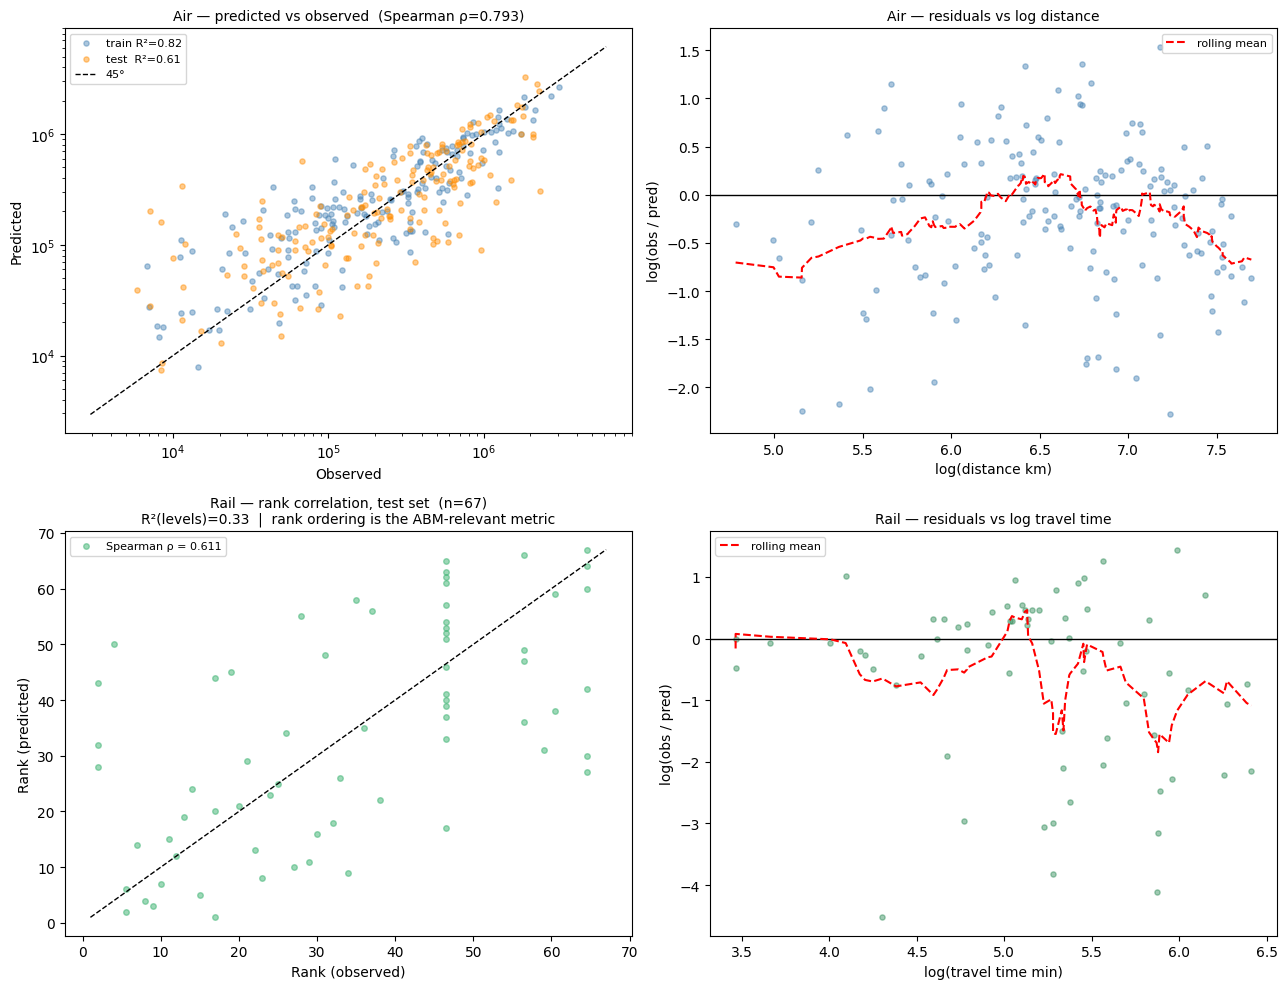

Air:  R²(test)=0.610  Spearman=0.793
Rail: R²(test)=0.333  Spearman=0.611
Saved gravity_diagnostic.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

def pv_ob_plot(ax, y_obs_tr, yhat_tr, y_obs_te, yhat_te, r2_tr, r2_te, title):
    ax.scatter(y_obs_tr, yhat_tr, s=14, alpha=0.45, color="steelblue",
               label=f"train R²={r2_tr:.2f}")
    ax.scatter(y_obs_te, yhat_te, s=14, alpha=0.45, color="darkorange",
               label=f"test  R²={r2_te:.2f}")
    lo = min(y_obs_tr.min(), y_obs_te.min()) * 0.5
    hi = max(y_obs_tr.max(), y_obs_te.max()) * 2.0
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="45°")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Observed"); ax.set_ylabel("Predicted")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)

def rank_plot(ax, y_obs_te, yhat_te, spearman, title):
    n = len(y_obs_te)
    r_obs  = stats.rankdata(y_obs_te)
    r_pred = stats.rankdata(yhat_te)
    ax.scatter(r_obs, r_pred, s=16, alpha=0.5, color="mediumseagreen",
               label=f"Spearman ρ = {spearman:.3f}")
    ax.plot([1, n], [1, n], "k--", lw=1)
    ax.set_xlabel("Rank (observed)"); ax.set_ylabel("Rank (predicted)")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)

def resid_plot(ax, x_vals, y_obs, yhat, xlabel, title, color):
    resid = np.log((np.array(y_obs) + 1) / (np.array(yhat) + 1))
    ax.scatter(x_vals, resid, s=14, alpha=0.45, color=color)
    ax.axhline(0, color="black", lw=1)
    order = np.argsort(x_vals)
    xs = np.array(x_vals)[order]; rs = resid[order]
    w  = max(1, len(xs) // 8)
    rm = pd.Series(rs).rolling(w, center=True, min_periods=1).mean().values
    ax.plot(xs, rm, "r--", lw=1.5, label="rolling mean")
    ax.set_xlabel(xlabel); ax.set_ylabel("log(obs / pred)")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)

# ── Air: level scatter + residuals ───────────────────────────────────────────
pv_ob_plot(axes[0, 0],
    tr_air["air_pax"], yhat_tr_air,
    te_air["air_pax"], yhat_te_air,
    metrics_air["r2_train"], metrics_air["r2_test"],
    f"Air — predicted vs observed  (Spearman ρ={metrics_air['spearman']:.3f})")

resid_plot(axes[0, 1],
    tr_air["log_d"], tr_air["air_pax"], yhat_tr_air,
    "log(distance km)", "Air — residuals vs log distance", "steelblue")

# ── Rail: rank-rank + residuals (level scatter omitted — proxy DV compression)
rank_plot(axes[1, 0],
    y_te_r, yhat_te_rail,
    metrics_rail["spearman"],
    f"Rail — rank correlation, test set  (n={metrics_rail['n_test']})\n"
    f"R²(levels)={metrics_rail['r2_test']:.2f}  |  rank ordering is the ABM-relevant metric")

resid_plot(axes[1, 1],
    tr_rail["log_tt"], y_tr_r, yhat_tr_rail,
    "log(travel time min)", "Rail — residuals vs log travel time", "seagreen")

fig.tight_layout()
fig.savefig(os.path.join(DATA_DIR, "gravity_diagnostic.png"), dpi=130, bbox_inches="tight")
plt.show()
print(f"Air:  R²(test)={metrics_air['r2_test']:.3f}  Spearman={metrics_air['spearman']:.3f}")
print(f"Rail: R²(test)={metrics_rail['r2_test']:.3f}  Spearman={metrics_rail['spearman']:.3f}")
print("Saved gravity_diagnostic.png")

## 6. Apply both models to full 53-city grid

Predict V_air and V_rail for all 1378 undirected pairs.
- V_air is zeroed for pairs with no observed air service (has_air = False)
- V_rail is zeroed for pairs with no observed rail service (has_rail = False)
- Combined weight = V_air + V_rail
- air_share = V_air / (V_air + V_rail)

In [6]:
# Build full grid
city_list = sorted(coord.keys())
all_pairs = []
for i, a in enumerate(city_list):
    for b in city_list[i+1:]:
        all_pairs.append({"city_a": a, "city_b": b,
                          "distance_km": hav(a, b, coord)})
grid = pd.DataFrame(all_pairs)
grid["log_d"] = np.log(grid["distance_km"])
print(f"Full grid: {len(grid)} pairs  (53×52/2 = {53*52//2})")

# ── Air model: extract city FEs + params ─────────────────────────────────────
def get_fe(model, prefix="c_"):
    return {k.replace(prefix, ""): float(v)
            for k, v in model.params.items() if k.startswith(prefix)}

fe_air    = get_fe(m_air)
const_air = float(m_air.params["const"])
gamma_air = float(-m_air.params["log_d"])

# ── Rail model: extract params ────────────────────────────────────────────────
const_rail    = float(m_rail.params["const"])
beta_pop_prod = float(m_rail.params["log_pop_prod"])
beta_pop_imb  = float(m_rail.params["log_pop_imb"])
gamma_rail    = float(-m_rail.params["log_tt"])
delta_country = float(m_rail.params["same_country"])

# Travel-time lookup; fallback = distance / 120 km/h
AVG_RAIL_SPEED = 120.0
tt_map = rail_ic.set_index(["city_a","city_b"])["travel_time_min"].to_dict()

def get_tt(ca, cb, dist_km):
    tt = tt_map.get((ca, cb), tt_map.get((cb, ca), dist_km / AVG_RAIL_SPEED * 60.0))
    return max(tt, 10.0)

def pred_air(row):
    return float(np.exp(const_air
                        + fe_air.get(row["city_a"], 0.)
                        + fe_air.get(row["city_b"], 0.)
                        - gamma_air * row["log_d"]))

def pred_rail(row):
    pop_a  = pop_map.get(row["city_a"], 1000.)
    pop_b  = pop_map.get(row["city_b"], 1000.)
    log_pp = np.log(pop_a * pop_b)
    log_pi = abs(np.log(pop_a) - np.log(pop_b))
    log_tt = np.log(get_tt(row["city_a"], row["city_b"], row["distance_km"]))
    same_c = 1.0 if country_map.get(row["city_a"]) == country_map.get(row["city_b"]) else 0.0
    return float(np.exp(const_rail
                        + beta_pop_prod * log_pp
                        + beta_pop_imb  * log_pi
                        - gamma_rail    * log_tt
                        + delta_country * same_c))

grid["V_air_raw"]  = grid.apply(pred_air,  axis=1)
grid["V_rail_raw"] = grid.apply(pred_rail, axis=1)

# Merge service flags
flags = df_all[["city_a","city_b","has_air","has_rail"]].copy()
grid  = pd.merge(grid, flags, on=["city_a","city_b"], how="left")
grid["has_air"]  = grid["has_air"].fillna(False).infer_objects(copy=False)
grid["has_rail"] = grid["has_rail"].fillna(False).infer_objects(copy=False)

grid["V_air"]  = np.where(grid["has_air"],  grid["V_air_raw"],  0.0)
grid["V_rail"] = np.where(grid["has_rail"], grid["V_rail_raw"], 0.0)

grid["V_total"]    = grid["V_air"] + grid["V_rail"]
grid["weight"]     = grid["V_total"] / grid["V_total"].sum()
grid["air_share"]  = np.where(grid["V_total"] > 0,
                               grid["V_air"] / grid["V_total"], 0.5)
grid["rail_share"] = 1 - grid["air_share"]

print(f"Pairs with air service:   {grid['has_air'].sum()}")
print(f"Pairs with rail service:  {grid['has_rail'].sum()}")
print(f"Pairs with both:          {(grid['has_air'] & grid['has_rail']).sum()}")
print(f"Pairs with neither (V=0): {(grid['V_total']==0).sum()}")
print()
print(f"Overall weighted air share:  {(grid['weight']*grid['air_share']).sum():.1%}")
print(f"Overall weighted rail share: {(grid['weight']*grid['rail_share']).sum():.1%}")

print("\nTop 15 highest-weight pairs:")
print(grid.nlargest(15, "weight")
          [["city_a","city_b","distance_km","V_air","V_rail","air_share","weight"]]
          .to_string(index=False))


Full grid: 1378 pairs  (53×52/2 = 1378)
Pairs with air service:   355
Pairs with rail service:  157
Pairs with both:          57
Pairs with neither (V=0): 923

Overall weighted air share:  53.9%
Overall weighted rail share: 46.1%

Top 15 highest-weight pairs:
   city_a     city_b  distance_km        V_air       V_rail  air_share   weight
   London      Paris   343.770887 3.274602e+06 6.989107e+05   0.824108 0.014844
   London     Madrid  1263.580385 2.833925e+06 0.000000e+00   1.000000 0.010587
Barcelona     Madrid   504.241642 1.763068e+06 9.226244e+05   0.656467 0.010033
Amsterdam     London   356.930636 2.654733e+06 0.000000e+00   1.000000 0.009917
Barcelona     London  1138.644468 2.439902e+06 0.000000e+00   1.000000 0.009115
    Lille      Paris   204.381601 0.000000e+00 2.275117e+06   0.000000 0.008499
Rotterdam    Utrecht    47.829890 0.000000e+00 2.248754e+06   0.000000 0.008401
  Antwerp   Brussels    41.301509 0.000000e+00 2.216882e+06   0.000000 0.008282
   London      Milan

C:\Users\Surface\AppData\Local\Temp\ipykernel_14392\3433908185.py:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grid["has_air"]  = grid["has_air"].fillna(False).infer_objects(copy=False)
C:\Users\Surface\AppData\Local\Temp\ipykernel_14392\3433908185.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grid["has_rail"] = grid["has_rail"].fillna(False).infer_objects(copy=False)


## 7. Modal split sanity check

Most rail-dominated routes (both modes present):
   city_a     city_b  distance_km  air_share
    Milan     Naples   657.509021   0.015679
     Lyon  Marseille   275.917252   0.020280
     Lyon Strasbourg   383.798229   0.026524
     Lyon   Toulouse   359.563509   0.038431
  Cologne  Stuttgart   287.536167   0.043280
Amsterdam  Rotterdam    57.492458   0.044645
 Brussels  Rotterdam   119.549360   0.050922
     Lyon      Paris   393.223311   0.070261
    Milan      Turin   125.483539   0.082701
Marseille   Toulouse   319.643101   0.089835

Most air-dominated routes (both modes present):
   city_a city_b  distance_km  air_share
   London  Paris   343.770887   0.824108
Barcelona  Paris   830.160704   0.764560
Frankfurt Zurich   305.816326   0.724849
Frankfurt  Paris   478.516264   0.668100
Barcelona Madrid   504.241642   0.656467
   Munich Vienna   355.716984   0.654385
   Vienna Zurich   591.565100   0.653104
 Brussels Munich   602.464644   0.647219
Frankfurt Munich   304.326894   0.6161

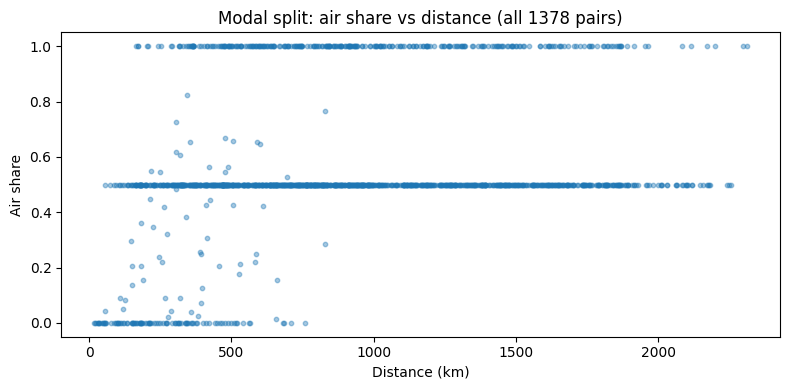

In [7]:
both = grid[grid["has_air"] & grid["has_rail"]].copy()

print("Most rail-dominated routes (both modes present):")
print(both.nsmallest(10, "air_share")[["city_a","city_b","distance_km","air_share"]].to_string(index=False))
print()
print("Most air-dominated routes (both modes present):")
print(both.nlargest(10, "air_share")[["city_a","city_b","distance_km","air_share"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(grid["distance_km"], grid["air_share"], s=10, alpha=0.4)
ax.set_xlabel("Distance (km)"); ax.set_ylabel("Air share")
ax.set_title("Modal split: air share vs distance (all 1378 pairs)")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 8. Save outputs

In [8]:
# gravity_weights.csv
weights_out = grid[["city_a","city_b","distance_km",
                     "V_air","V_rail","V_total","weight",
                     "air_share","rail_share","has_air","has_rail"]].copy()
weights_path = os.path.join(DATA_DIR, "gravity_weights.csv")
weights_out.to_csv(weights_path, index=False)
print(f"Saved -> {weights_path}  ({len(weights_out)} rows)")

# modal_split.csv  (clean version for ABM)
modal_out = grid[["city_a","city_b","air_share","rail_share","has_air","has_rail"]].copy()
modal_path = os.path.join(DATA_DIR, "modal_split.csv")
modal_out.to_csv(modal_path, index=False)
print(f"Saved -> {modal_path}  ({len(modal_out)} rows)")

# gravity_params.json
params_v4 = {
    "version": "v4",
    "model": "dual_mode_structural_gravity",
    "formula": "V_mode(a,b) = exp(mu_a_mode + mu_b_mode - gamma_mode * log(d_ab))",
    "estimator": "PPML (Santos Silva & Tenreyro 2006)",
    "city_FE": "Anderson & van Wincoop (2003)",
    "city_coverage": 53,
    "rail_min_km_for_calibration": RAIL_MIN_KM,
    "air": {
        "dependent_var": "air_pax = OPDI_flights x typecode_seats x 0.80",
        "calibration_filter": "air_pax > 0",
        "n_train": metrics_air["n_train"],
        "n_test":  metrics_air["n_test"],
        "gamma":   metrics_air["gamma"],
        "p_gamma": metrics_air["p_gamma"],
        "r2_train_levels": metrics_air["r2_train"],
        "r2_test_levels":  metrics_air["r2_test"],
        "spearman_test":   metrics_air["spearman"],
        "city_fe": {k.replace("c_",""): float(v)
                    for k,v in m_air.params.items() if k.startswith("c_")},
        "const": const_air,
    },
    "rail": {
        "dependent_var": "rail_pax = GTFS_freq/day x 365 x seats x load_factor (Eurostat)",
        "calibration_filter": f"rail_pax > 0 AND distance_km >= {RAIL_MIN_KM}",
        "n_train": metrics_rail["n_train"],
        "n_test":  metrics_rail["n_test"],
        "gamma":   metrics_rail["gamma"],
        "p_gamma": metrics_rail["p_gamma"],
        "r2_train_levels": metrics_rail["r2_train"],
        "r2_test_levels":  metrics_rail["r2_test"],
        "spearman_test":   metrics_rail["spearman"],
        "city_fe": {k.replace("c_",""): float(v)
                    for k,v in m_rail.params.items() if k.startswith("c_")},
        "const": const_rail,
    },
    "comparison_to_v3": {
        "v3_model": "single air-only PPML",
        "v3_r2_test_levels": 0.758,
        "v3_spearman": 0.846,
        "v3_city_coverage": 27,
    }
}
params_path = os.path.join(DATA_DIR, "gravity_params.json")
with open(params_path, "w") as f:
    json.dump(params_v4, f, indent=2)
print(f"Saved -> {params_path}")

print(f"\n=== v4 FINAL SUMMARY ===")
print(f"  Cities: {params_v4['city_coverage']}  (v3: 27)")
print(f"  Air  gamma: {metrics_air['gamma']:.4f}   R2(test): {metrics_air['r2_test']:.4f}   Spearman: {metrics_air['spearman']:.4f}")
print(f"  Rail gamma: {metrics_rail['gamma']:.4f}   R2(test): {metrics_rail['r2_test']:.4f}   Spearman: {metrics_rail['spearman']:.4f}")
print(f"  v3   gamma: 0.1958      R2(test): 0.7579      Spearman: 0.8459")

Saved -> data\gravity_weights.csv  (1378 rows)
Saved -> data\modal_split.csv  (1378 rows)
Saved -> data\gravity_params.json

=== v4 FINAL SUMMARY ===
  Cities: 53  (v3: 27)
  Air  gamma: 0.1892   R2(test): 0.6100   Spearman: 0.7929
  Rail gamma: 0.4221   R2(test): 0.3327   Spearman: 0.6106
  v3   gamma: 0.1958      R2(test): 0.7579      Spearman: 0.8459


## 9. Report (Section 5.2)

Demand calibration uses a dual-mode structural gravity model, fitting separate
Poisson Pseudo-Maximum-Likelihood (PPML) estimators for air and rail
(Santos Silva & Tenreyro 2006). 

The air model includes city fixed effects
capturing hub structure and market potential (Anderson & van Wincoop 2003):

    V_air(a,b) = exp(mu_a + mu_b - gamma_air * log d_ab)

The rail model uses symmetric population terms and travel time in place of
city fixed effects, which overfit catastrophically on 134 intercity pairs
(prior run: R2_train=0.994, R2_test=0.008, gamma=+3.85). Following the
traditional gravity formulation (Tinbergen 1962):

    V_rail(a,b) = exp(const + theta*log(pop_a*pop_b) + phi*|delta log pop| - gamma*log t_ab + delta*same_country)

where t_ab is the minimum scheduled travel time (GTFS) and same_country is
a cross-border friction dummy.

In [12]:
w_air_share  = (grid["weight"] * grid["air_share"]).sum()
w_rail_share = (grid["weight"] * grid["rail_share"]).sum()

print(f"""
Air volumes: EUROCONTROL OPDI (2022-2023), typecode seat capacities, 80% load factor (IATA European average). 
      
Rail volumes: GTFS frequency 
(capped at {metrics_rail['freq_cap']}/day to exclude commuter/regional trains) * 365 * seats * country load factor (Eurostat).

Fitted elasticities: gamma_air = {metrics_air['gamma']:.3f} (p<0.001),
gamma_rail = {metrics_rail['gamma']:.3f} (p<0.001, travel-time elasticity).

Air model fit (held-out test set): R2 = {metrics_air['r2_test']:.3f},
Spearman rho = {metrics_air['spearman']:.3f} (v3 benchmark: 0.758, 0.846).
Rail model fit: R2 = {metrics_rail['r2_test']:.3f}, Spearman rho = {metrics_rail['spearman']:.3f}.

Route-specific modal preference:
air_share(a,b) = V_air / (V_air + V_rail), yielding network averages of
{w_air_share:.0%} air / {w_rail_share:.0%} rail.
""")



Air volumes: EUROCONTROL OPDI (2022-2023), typecode seat capacities, 80% load factor (IATA European average). 

Rail volumes: GTFS frequency 
(capped at 20/day to exclude commuter/regional trains) * 365 * seats * country load factor (Eurostat).

Fitted elasticities: gamma_air = 0.189 (p<0.001),
gamma_rail = 0.422 (p<0.001, travel-time elasticity).

Air model fit (held-out test set): R2 = 0.610,
Spearman rho = 0.793 (v3 benchmark: 0.758, 0.846).
Rail model fit: R2 = 0.333, Spearman rho = 0.611.

Route-specific modal preference:
air_share(a,b) = V_air / (V_air + V_rail), yielding network averages of
54% air / 46% rail.

